## Customer Shopping Behaviour Analysis for Business Insights

## Objective
To analyze customer shopping behavior and identify key factors influencing purchase patterns to support business decision-making.

In [116]:
import pandas as pd

df = pd.read_csv("customer_shopping_behavior.csv")

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [118]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [119]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [120]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [121]:
# Filling missing values in review rating with mean
df['Review Rating'].fillna(df['Review Rating'].mean(), inplace=True)

In [122]:
# Checking if any missing values remain
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [123]:
# Analysis 1: Which product category generates the highest total revenue?

# Group data by Category and calculate total purchase amount
category_sales = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

# Display result
category_sales

Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64

In [124]:
# Import Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

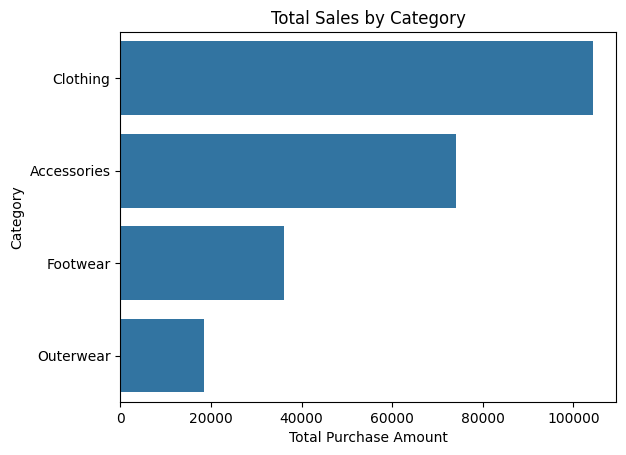

In [125]:
# Bar chart for total sales by category
sns.barplot(x=category_sales.values, y=category_sales.index)

plt.title("Total Sales by Category")
plt.xlabel("Total Purchase Amount")
plt.ylabel("Category")
plt.show()

In [126]:
# Analysis 2: Who spends more based on gender?
import pandas as pd 
df = pd.read_csv("customer_shopping_behavior.csv")
# Group data by Gender and calculate average purchase amount
gender_spending = df.groupby('Gender')['Purchase Amount (USD)'].mean()

# Display result
gender_spending

Gender
Female    60.249199
Male      59.536199
Name: Purchase Amount (USD), dtype: float64

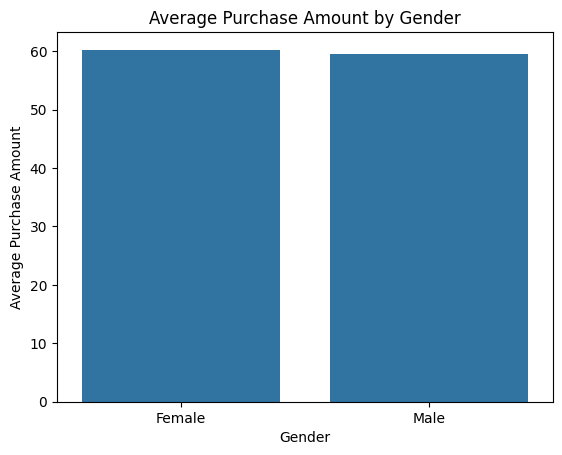

In [127]:
# Bar chart for average spending by gender
sns.barplot(x=gender_spending.index, y=gender_spending.values)

plt.title('Average Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Purchase Amount')
plt.show()

In [128]:
# Analysis 3: Which age group spends the most on average?

# Group data by Age and calculate average purchase amount
age_spending = df.groupby('Age')['Purchase Amount (USD)'].mean().sort_values(ascending=False)

# Display result
age_spending

Age
53    67.885714
49    66.095238
44    64.941176
28    64.607595
61    64.184615
21    64.101449
51    63.902778
65    63.750000
54    63.638554
25    63.200000
24    63.102941
33    62.857143
69    62.318182
30    61.605634
31    61.569620
37    61.519481
41    61.418605
26    61.043478
19    61.000000
36    60.959459
22    60.772727
67    60.333333
63    60.253333
18    59.985507
35    59.916667
57    59.770115
39    59.661765
38    59.557143
43    59.468354
50    59.397590
55    59.369863
29    59.197368
32    58.487805
52    58.287671
56    58.013514
59    57.973333
62    57.939759
60    57.384615
66    57.253521
68    57.160000
64    57.123288
70    56.865672
46    56.815789
23    56.746479
45    56.736111
47    56.605634
40    55.916667
58    55.814815
34    55.279412
20    55.225806
42    54.462500
27    53.734940
48    52.588235
Name: Purchase Amount (USD), dtype: float64

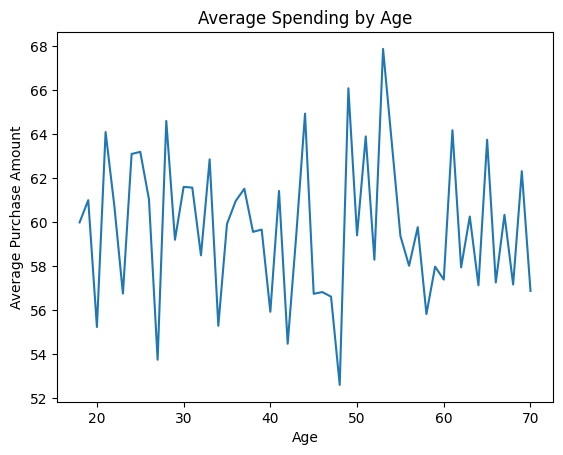

In [129]:
# Line chart for age vs average spending
age_spending.sort_index().plot(kind='line')

plt.title("Average Spending by Age")
plt.xlabel("Age")
plt.ylabel("Average Purchase Amount")
plt.show()

## Category Insight
- Clothing is the highest revenue-generating category.

## Gender Spending Insight
- Female customers have a higher average purchase amount than male customers.

## Age Insight
- Customers in the age group of 53 years spend the most on average.

In [130]:
#Analysis 4: Which season has highest sales
# Total sales by season
# Store result in variable
season_sales = df.groupby('Season')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

season_sales

Season
Fall      60018
Spring    58679
Winter    58607
Summer    55777
Name: Purchase Amount (USD), dtype: int64

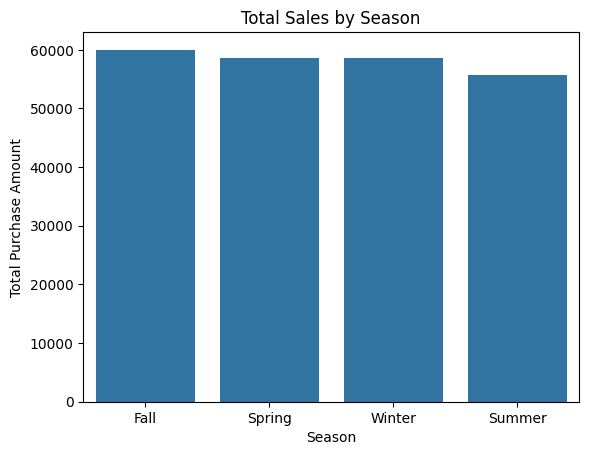

In [131]:
# Bar chart for total sales by season
sns.barplot(x=season_sales.index, y=season_sales.values)

plt.title("Total Sales by Season")
plt.xlabel("Season")
plt.ylabel("Total Purchase Amount")
plt.show()

In [132]:
# Analysis 5: Which is the preferred payment method?
# Most used payment methods
Payment_counts = df['Payment Method'].value_counts()

Payment_counts

Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

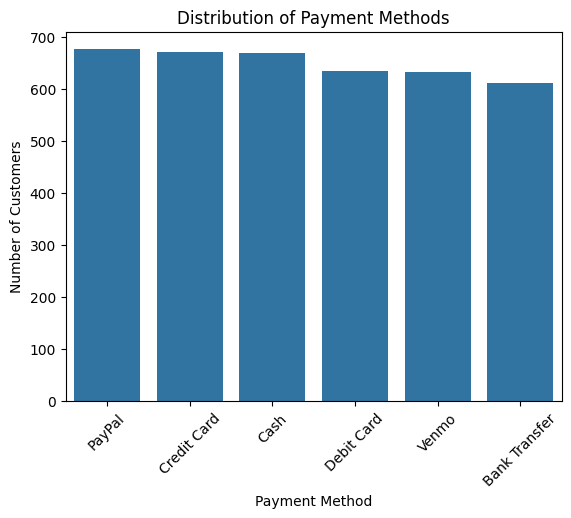

In [133]:
# Bar chart for payment method distribution
sns.barplot(x=Payment_counts.index, y=Payment_counts.values)

plt.title("Distribution of Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

In [134]:
# Analysis 6: Do subscribers spend more?
# Compare spending of subscribers vs non-subscribers
Subscription_spending = df.groupby('Subscription Status')['Purchase Amount (USD)'].mean()

Subscription_spending

Subscription Status
No     59.865121
Yes    59.491928
Name: Purchase Amount (USD), dtype: float64

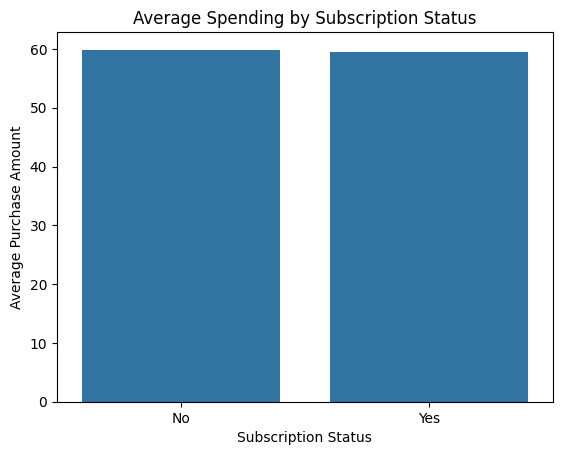

In [135]:
# Bar chart for subscription impact
sns.barplot(x=Subscription_spending.index, y=Subscription_spending.values)

plt.title("Average Spending by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Average Purchase Amount")
plt.show()

In [136]:
# Analysis 7: Do discounts increase spending?
# Impact of discount on spending
Applied_discount = df.groupby('Discount Applied')['Purchase Amount (USD)'].mean()

Applied_discount

Discount Applied
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64

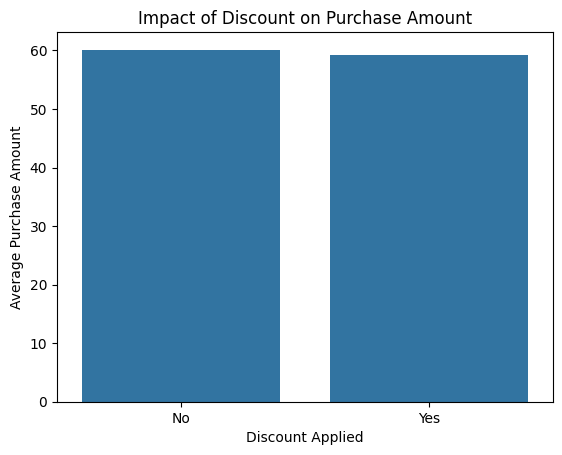

In [137]:
# Bar chart for discount impact
sns.barplot(x=Applied_discount.index, y=Applied_discount.values)

plt.title("Impact of Discount on Purchase Amount")
plt.xlabel("Discount Applied")
plt.ylabel("Average Purchase Amount")
plt.show()

In [138]:
# Analysis 8: How to purchase frequency affect customer spending behaviour?
# Analyze average spending based on purchase frequency
frequency_spending = df.groupby('Frequency of Purchases')['Purchase Amount (USD)'].mean().sort_values(ascending=False)

frequency_spending

Frequency of Purchases
Bi-Weekly         60.694698
Annually          60.173077
Every 3 Months    60.082192
Quarterly         59.984014
Monthly           59.330922
Fortnightly       59.053506
Weekly            58.972171
Name: Purchase Amount (USD), dtype: float64

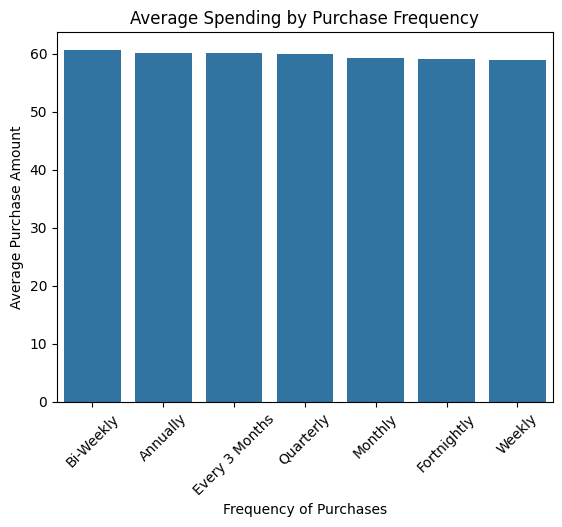

In [139]:
# Bar chart for purchase frequency vs spending
sns.barplot(x=frequency_spending.index, y=frequency_spending.values)

plt.title("Average Spending by Purchase Frequency")
plt.xlabel("Frequency of Purchases")
plt.ylabel("Average Purchase Amount")
plt.xticks(rotation=45)
plt.show()

## Season vs Sales Insight
- Fall season generates the highest total sales among all seasons.
- Summer has the lowest sales, indicating lower customer spending during this period.
- This suggests that demand is higher during Fall, possibly due to seasonal shopping trends.

## Payment Method Insight
- PayPal is the most preferred payment method among customers.
- Credit Card and Cash are also widely used, showing multiple strong payment preferences.
- Bank Transfer is the least used method, indicating lower customer preference.

## Subscription Impact Insight
- There is very little difference in spending between subscribed and non-subscribed customers.
- Non-subscribed customers spend slightly more on average than subscribed ones.
- This suggests that the subscription program is not significantly influencing customer spending.

## Discount Impact Insight
- Customers who did not receive discounts spend slightly more than those who did.
- This indicates that discounts are not strongly increasing purchase amounts.
- It suggests that customers may be willing to spend regardless of discounts.

## Purchase Frequency Insight
- Customers who purchase bi-weekly have the highest average spending.
- Weekly customers have slightly lower spending compared to other groups.
- This shows that moderately frequent buyers contribute more to revenue than very frequent or rare buyers.

## Business Recommendations

- Focus marketing and promotional campaigns on the Clothing category, as it generates the highest revenue.

- Target female customers with personalized offers and campaigns, since they have higher average spending.

- Design premium or targeted marketing strategies for customers around the age of 53, as they represent the highest spending group.

- Increase marketing efforts during the Fall season to maximize sales, as it shows the highest revenue.

- Improve subscription benefits and value proposition, since subscription status is not significantly impacting customer spending.

- Reevaluate discount strategies, as discounts are not leading to higher purchase amounts and may not be effective.

- Introduce loyalty programs for bi-weekly customers, as they show the highest spending and contribute significantly to revenue.

- Offer multiple payment options with a focus on popular methods like PayPal, Credit Card, and Cash to enhance customer convenience.

In [140]:
# Fill missing values again
df['Review Rating'].fillna(df['Review Rating'].mean(), inplace=True)

In [141]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [142]:
df.to_csv("cleaned_data.csv", index=False)